# Annual Rainfall Comparison Between Seattle and Philadelphia

### Introduction

>The purpose of this project is to analyze rainfall data for Seattle and Philadelphia to answer the following questions: Which city receives more rainfall per year, and which city has a higher proportion of rainy days per year?

### Data
>The data analyzed in this project was sourced from the National Oceanic and Atmospheric Administration (NOAA) through the NOAA Climate Data Online (CDO) portal. The data is from two weather stations, one in Seattle and one in Philadelphia. The data spans a total of five years, from January 1, 2018, to December 31, 2022.
The data can also be accessed through the following link:
https://www.ncei.noaa.gov/cdo-web/


## Data Preperation

### Import NOAA Data for Seattle

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style("whitegrid")

df_seattle = pd.read_csv("/Users/michael/Documents/SeattleU/5100/Weather/data/seattle_rain.csv")

### Import NOAA Data for Philadelphia

Due to the max size for a single NOAA download, the Philadelphia dataset was downloaded in three different sections

In [2]:
df_phl1 = pd.read_csv("/Users/michael/Documents/SeattleU/5100/Weather/data/phl_rain1.csv")
df_phl2 = pd.read_csv("/Users/michael/Documents/SeattleU/5100/Weather/data/phl_rain2.csv")
df_phl3 = pd.read_csv("/Users/michael/Documents/SeattleU/5100/Weather/data/phl_rain3.csv")

Combine data from 3 seperate dataframes into one, combined dataframe

In [3]:
df_phl = pd.concat([df_phl1, df_phl2, df_phl3], ignore_index=True)

Inspect the dataframe and learn about the structure of the data

In [4]:
df_phl.head()

,STATION,NAME,DATE,PRCP,SNOW,SNWD
0,USW00013739,"PHILADELPHIA INTERNATIONAL AIRPORT, PA US",2018-01-01,0.00,0.0,1.2
1,USW00013739,"PHILADELPHIA INTERNATIONAL AIRPORT, PA US",2018-01-02,0.00,0.0,0.0
2,USW00013739,"PHILADELPHIA INTERNATIONAL AIRPORT, PA US",2018-01-03,0.00,0.0,0.0
3,USW00013739,"PHILADELPHIA INTERNATIONAL AIRPORT, PA US",2018-01-04,0.25,4.1,0.0
4,USW00013739,"PHILADELPHIA INTERNATIONAL AIRPORT, PA US",2018-01-05,0.00,0.0,3.1


In [5]:
df_phl["STATION"].unique()

array(['USW00013739'], dtype=object)

In [6]:
df_phl["STATION"].nunique()

1

In [7]:
df_phl['DATE'].agg(['min','max'])

min    2018-01-01
max    2022-12-31
Name: DATE, dtype: object

In [9]:
df_phl.dtypes

STATION            object
NAME               object
DATE       datetime64[ns]
PRCP              float64
SNOW              float64
SNWD              float64
dtype: object

In [11]:
print(df_seattle.shape)
print(df_phl.shape)

(1658, 10)
(1826, 6)


Convert the date column from an object datatype to datetime64

In [8]:
df_phl["DATE"] = pd.to_datetime(df_phl["DATE"])
df_seattle["DATE"] = pd.to_datetime(df_seattle["DATE"])

/var/folders/dv/p_52lnsx0nb3phkqsyqzbtj40000gn/T/ipykernel_11984/2014070821.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_seattle["DATE"] = pd.to_datetime(df_seattle["DATE"])


In [10]:
df_seattle.dtypes

STATION            object
NAME               object
DATE       datetime64[ns]
DAPR              float64
MDPR              float64
PRCP              float64
SNOW              float64
SNWD              float64
WESD              float64
WESF              float64
dtype: object

Merge the Seattle and Philadelphia dataframes

In [12]:
df = df_phl[['DATE','PRCP']].merge(df_seattle[['DATE','PRCP']], on='DATE', how='outer')

In [13]:
df.head()

,DATE,PRCP_x,PRCP_y
0,2018-01-01,0.00,0.00
1,2018-01-02,0.00,0.00
2,2018-01-03,0.00,0.00
3,2018-01-04,0.25,0.00
4,2018-01-05,0.00,0.25


Convert the data from a wide format to a long format

In [14]:
df = pd.melt(df, id_vars='DATE', var_name='city', value_name='precipitation')

In [51]:
df["city"].unique()

array(['PHL', 'SEA'], dtype=object)

Rename 'PRCP_x' and 'PRCP_y' to match city names

In [ ]:
df.loc[df['city']== 'PRCP_x', 'city'] = 'PHL'
df.loc[df['city']== 'PRCP_y', 'city'] = 'SEA'

Rename the 'DATE' column to match the lowercase formatting of other columns in the dataframe

In [19]:
df = df.rename(columns={'DATE': 'date'})

Add a column for day of the year 

In [52]:
df['day_of_year'] = pd.DatetimeIndex(df['date']).day_of_year

Inspect the cleaned dataset, that has been prepared for analysis

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   date               3652 non-null   object 
 1   city               3652 non-null   object 
 2   precipitation      3652 non-null   float64
 3   day_of_year        3652 non-null   int32  
 4   month              3652 non-null   int32  
 5   any_precipitation  3652 non-null   bool   
dtypes: bool(1), float64(1), int32(2), object(2)
memory usage: 117.8+ KB


In [21]:
df.notna().sum()

date             3652
city             3652
precipitation    3462
dtype: int64

In [22]:
df.isna().sum()

date               0
city               0
precipitation    190
dtype: int64

In [23]:
df.loc[df['city'] == 'SEA', 'precipitation'].isna().sum()

np.int64(190)

In [24]:
df.loc[df['city'] == 'STL', 'precipitation'].isna().sum()

np.int64(0)

In [26]:
df.head()

,date,city,precipitation,day_of_year
0,2018-01-01,PHL,0.00,1
1,2018-01-02,PHL,0.00,2
2,2018-01-03,PHL,0.00,3
3,2018-01-04,PHL,0.25,4
4,2018-01-05,PHL,0.00,5


Evaluate the data to find any initial patterns 

In [27]:
mean_day_precipitation=df.loc[
    df['city']=='SEA',
    ['precipitation','day_of_year']
].groupby(
    'day_of_year'
).mean()

In [28]:
mean_day_precipitation

,precipitation
day_of_year,
1,0.052000
2,0.150000
3,0.836000
4,0.370000
5,0.246667
...,...
362,0.120000
363,0.102000
364,0.268000


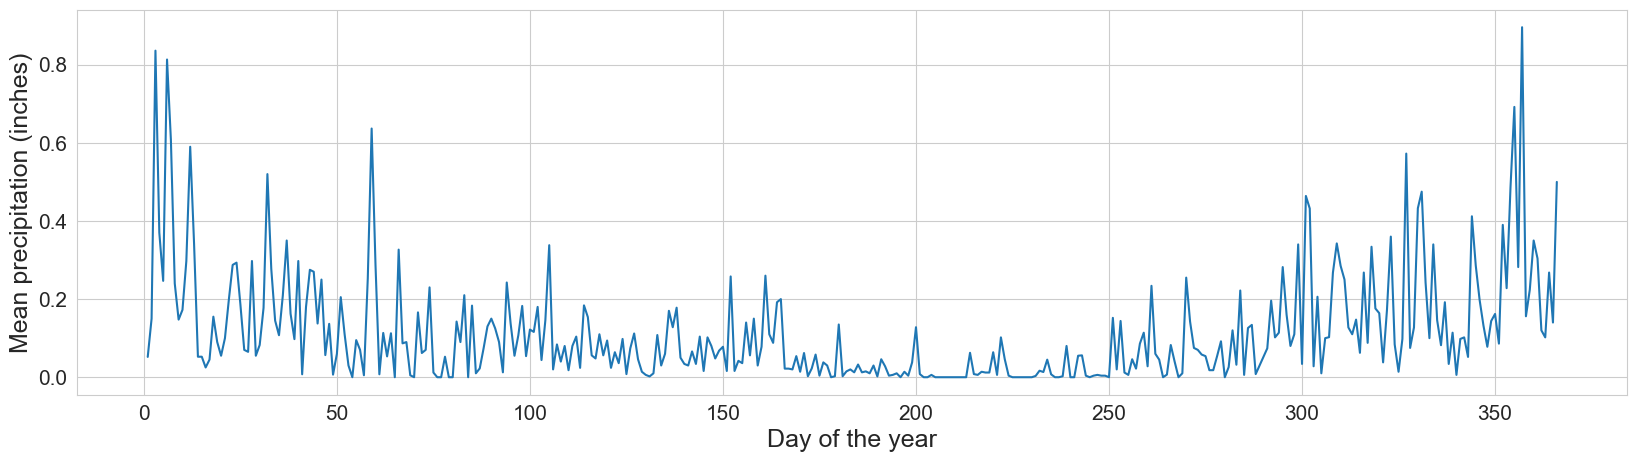

In [29]:
plt.figure(figsize=(20,5))

sns.lineplot(data=mean_day_precipitation, x='day_of_year', y='precipitation')

plt.xlabel('Day of the year', fontsize=18)
plt.ylabel('Mean precipitation (inches)', fontsize=18)

plt.tick_params(labelsize=15)

plt.show()

Indentified missing values, and assigned the mean to missing values 

In [ ]:
indices = np.where(df['precipitation'].isna() == True)[0]

for index in indices:
    df.loc[index,'precipitation'] = mean_day_precipitation.loc[df.loc[index, 'day_of_year']].values[0]

Export the cleaned dataframe that has been prepared for analysis

In [32]:
df.to_csv('/Users/michael/Documents/SeattleU/5100/Weather/data/clean_seattle_PHL_weather.csv', encoding='utf-8-sig', index=False)

## Analysis

### Mean Rainfall in Seattle and Philadelphia

The cleaned CSV file is imported into a DataFrame for analysis. Although this step would typically be performed in a separate notebook, it is included in the same notebook here for simplicity.

In [33]:
# import CSV to dataframe
df = pd.read_csv("/Users/michael/Documents/SeattleU/5100/Weather/data/clean_seattle_PHL_weather.csv")

An initial plot is created to find patterns

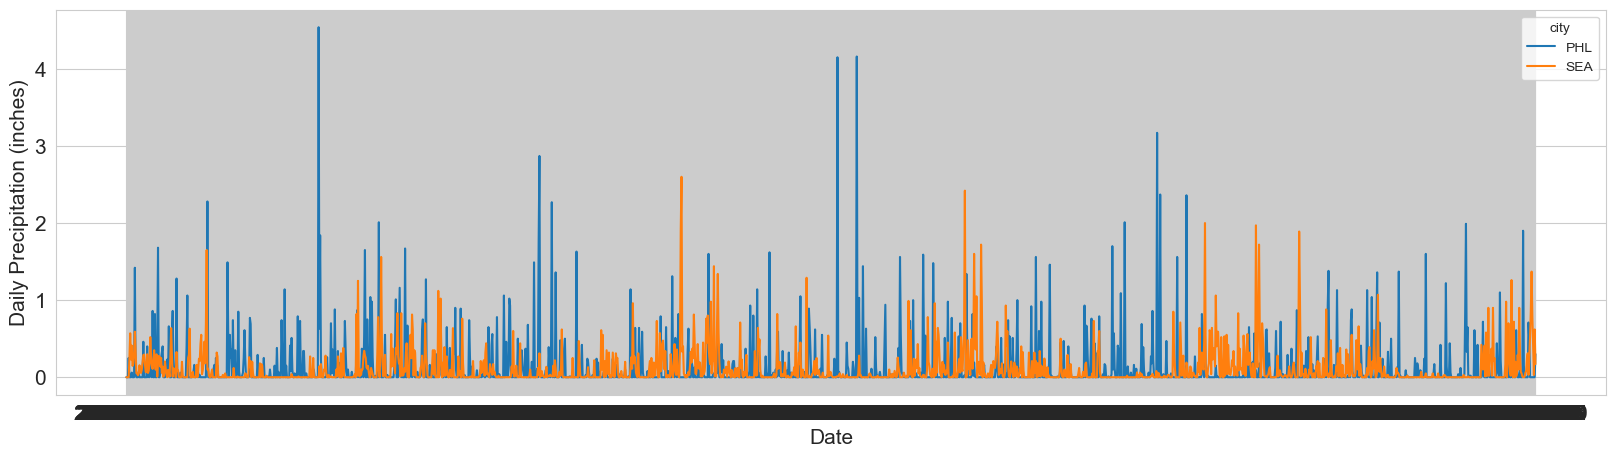

In [36]:
#create a plot to explore data for initial patterns
plt.figure(figsize=(20,5))

sns.lineplot(data=df, x='date', y='precipitation', hue='city')

plt.xlabel('Date', fontsize=15)
plt.ylabel('Daily Precipitation (inches)', fontsize=15)

plt.tick_params(labelsize=15)

plt.show()

A groupby function and the describe function is used to find initiale patterns in the rainfall data between the two cities

In [ ]:
df[['city','precipitation']].groupby('city').describe()

precipitation                                                
             count      mean       std  min  25%   50%   75%   max
city                                                              
PHL         1826.0  0.134189  0.362082  0.0  0.0  0.00  0.07  4.54
SEA         1826.0  0.113270  0.240516  0.0  0.0  0.01  0.12  2.60

A groupby function is used to find whch city averages more rainfall in inches per year

In [38]:
#compare the daily average rainfall to view differences
df[['city','precipitation']].groupby('city').mean()

,precipitation
city,
PHL,0.134189
SEA,0.113270


A barplot is created to visualize the mean rainfall per day in Seattle and Philadelphia

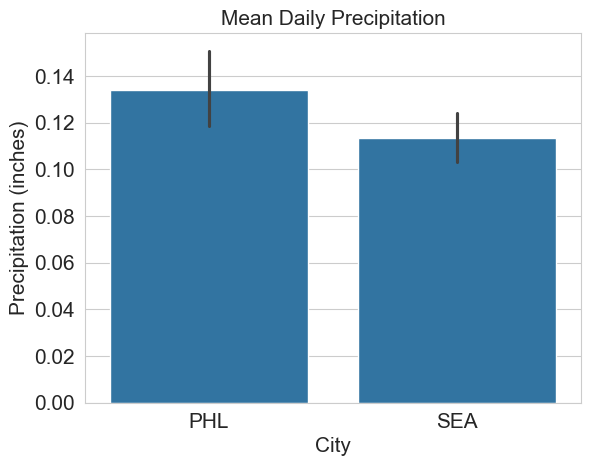

In [39]:
#create a barplot to compare mean rainfall
sns.barplot(data=df, x='city', y='precipitation')

plt.ylabel('Precipitation (inches)', fontsize=15)
plt.xlabel('City', fontsize=15)
plt.title('Mean Daily Precipitation', fontsize=15)

plt.tick_params(labelsize=15)


plt.savefig('/Users/michael/Documents/SeattleU/5100/Weather/reports/mean_daily_rainfall.png', dpi=300, bbox_inches='tight')

plt.show()

In [40]:
#create a new column called month and add a numerical value to represent the month, this make the data easier to visualize
df['month'] = pd.DatetimeIndex(df['date']).month

In [55]:
df.head()

,date,city,precipitation,day_of_year,month,any_precipitation
0,2018-01-01,PHL,0.00,1,1,False
1,2018-01-02,PHL,0.00,2,1,False
2,2018-01-03,PHL,0.00,3,1,False
3,2018-01-04,PHL,0.25,4,1,True
4,2018-01-05,PHL,0.00,5,1,False


In [42]:
#Return all unique month value to ensure that there are individual months in the data
df['month'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int32)

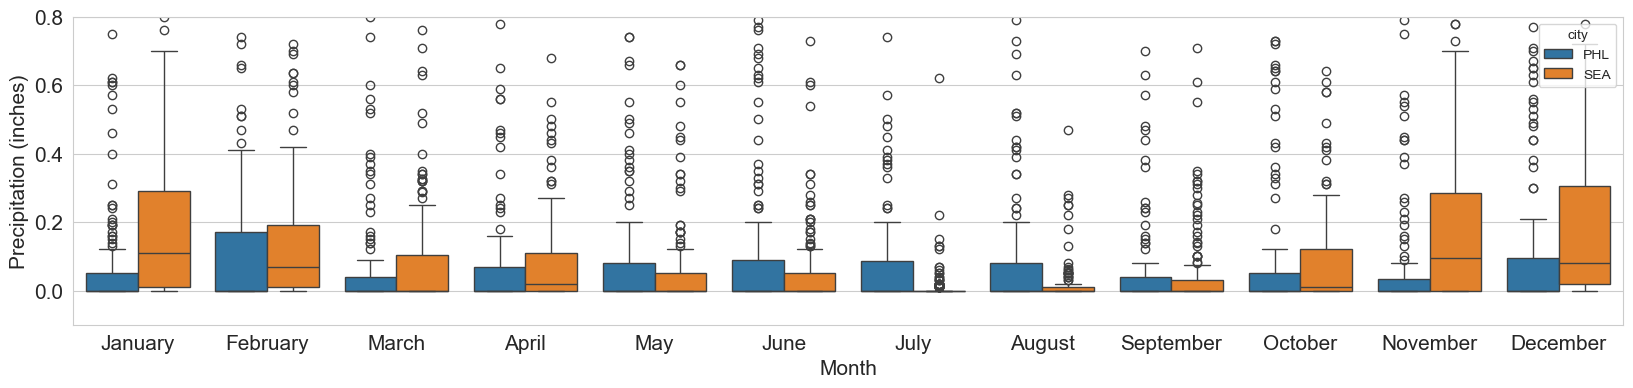

In [43]:
#Create a box plot to compare rainfall in different months
plt.figure(figsize=(20,4))

sns.boxplot(data=df, x='month', y='precipitation', hue='city')

plt.xlabel('Month', fontsize=15)
plt.ylabel('Precipitation (inches)', fontsize =15)
plt.ylim(-0.1, 0.8)

plt.tick_params(labelsize=15)

#Get month names and set x-axis tick labels
import calendar
month_names = list(calendar.month_name[1:])
plt.xticks(ticks=range(12), labels=month_names)

plt.show()

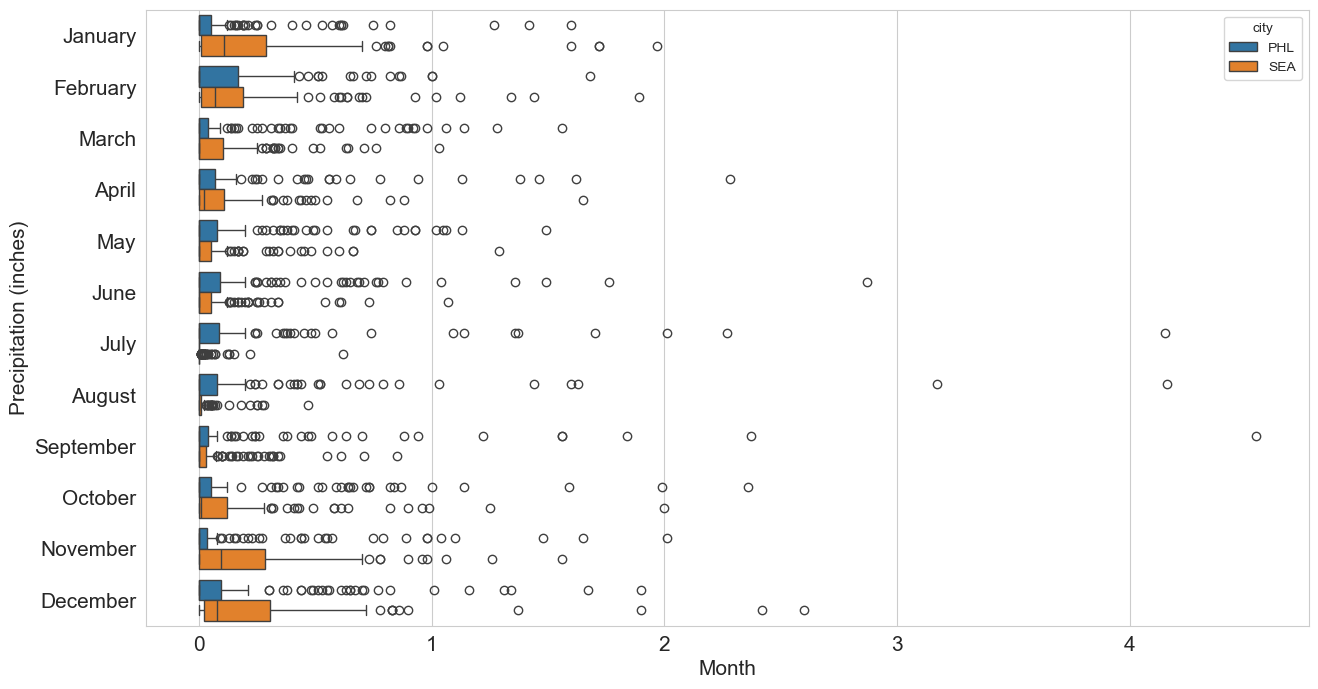

In [44]:
#Create a horizontal boxplot to better view data trends

plt.figure(figsize=(15,8))

sns.boxplot(data=df, x='precipitation', y='month', hue='city', orient='h')

plt.xlabel('Month', fontsize=15)
plt.ylabel('Precipitation (inches)', fontsize =15)

plt.tick_params(labelsize=15)
plt.yticks(ticks=range(12), labels=month_names)


plt.show()

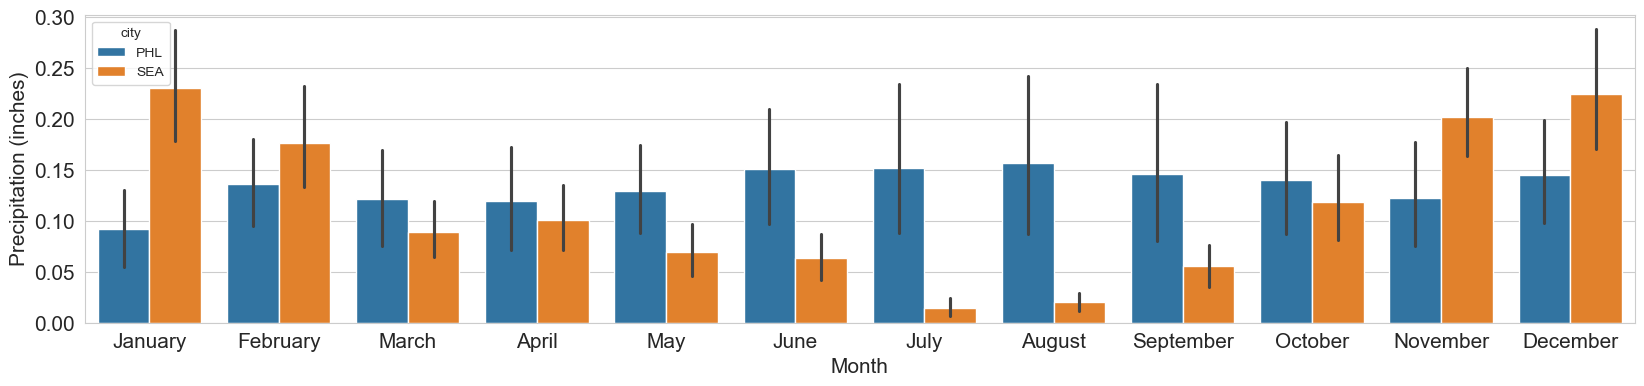

In [45]:
#This plots the mean precipitation each month

plt.figure(figsize=(20,4))

sns.barplot(data=df, x='month', y='precipitation', hue='city')

plt.xlabel('Month', fontsize=15)
plt.ylabel('Precipitation (inches)', fontsize=15)

plt.tick_params(labelsize=15)

plt.xticks(ticks=range(12), labels=month_names)

plt.savefig('/Users/michael/Documents/SeattleU/5100/Weather/reports/monthly_mean_rainfall.png', dpi=300, bbox_inches='tight')

plt.show()

In [46]:
#Compute the mean precipitation each month

df[['month', 'precipitation', 'city']].groupby(['month','city']).mean()

precipitation
month city               
1     PHL        0.092323
      SEA        0.230742
2     PHL        0.136596
      SEA        0.176472
3     PHL        0.121484
      SEA        0.089075
4     PHL        0.119400
      SEA        0.100483
5     PHL        0.129226
      SEA        0.069161
6     PHL        0.150533
      SEA        0.063167
7     PHL        0.151935
      SEA        0.013984
8     PHL        0.156774
      SEA        0.019995
9     PHL        0.145467
      SEA        0.055622
10    PHL        0.139677
      SEA        0.118452
11    PHL        0.122200
      SEA        0.201867
12    PHL        0.144903
      SEA        0.224903

### Proportion of rainy days in Seattle and Philadelphia

This next section focuses on finding which city recieved a greater proportion of rainy days throughout the year.

A new variable is created and added to the dataframe to indicate if there was any precipitation on a given day

In [56]:
df['any_precipitation'] = df['precipitation'] > 0

In [57]:
df.head()

,date,city,precipitation,day_of_year,month,any_precipitation
0,2018-01-01,PHL,0.00,1,1,False
1,2018-01-02,PHL,0.00,2,1,False
2,2018-01-03,PHL,0.00,3,1,False
3,2018-01-04,PHL,0.25,4,1,True
4,2018-01-05,PHL,0.00,5,1,False


A groupby function is used to find how Seattle and Philadelphia compared when looking at the proportion of days with rain

In [ ]:

df[['city','any_precipitation']].groupby('city').mean()

,any_precipitation
city,
PHL,0.358708
SEA,0.547097


In [68]:
df[['month','city','any_precipitation']].groupby(['month', 'city']).mean()

any_precipitation
month city                   
1     PHL            0.329032
      SEA            0.767742
2     PHL            0.460993
      SEA            0.815603
3     PHL            0.303226
      SEA            0.490323
4     PHL            0.400000
      SEA            0.606667
5     PHL            0.406452
      SEA            0.464516
6     PHL            0.360000
      SEA            0.440000
7     PHL            0.354839
      SEA            0.238710
8     PHL            0.348387
      SEA            0.290323
9     PHL            0.340000
      SEA            0.380000
10    PHL            0.380645
      SEA            0.541935
11    PHL            0.280000
      SEA            0.726667
12    PHL            0.348387
      SEA            0.825806

A plot is created to visualize the difference between Seattle and Philadelphia

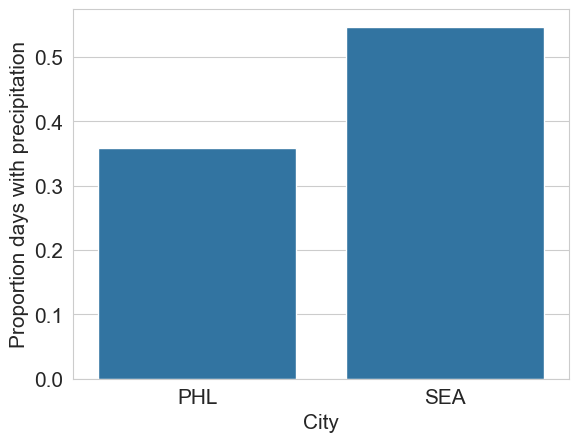

In [58]:
#Plot the proportion of days with any precipitation over the 5 years

sns.barplot(data=df, x='city', y='any_precipitation', errorbar=None)

plt.xlabel('City', fontsize=15)
plt.ylabel('Proportion days with precipitation', fontsize=15)

plt.tick_params(labelsize=15)


#Save file to reports folder

plt.savefig('/Users/michael/Documents/SeattleU/5100/Weather/reports/annual_rainfall_proportion.png', dpi=300, bbox_inches='tight')

plt.show()



A second plot is created to compare the proportion fo rainy days per month, to find any underlying trends

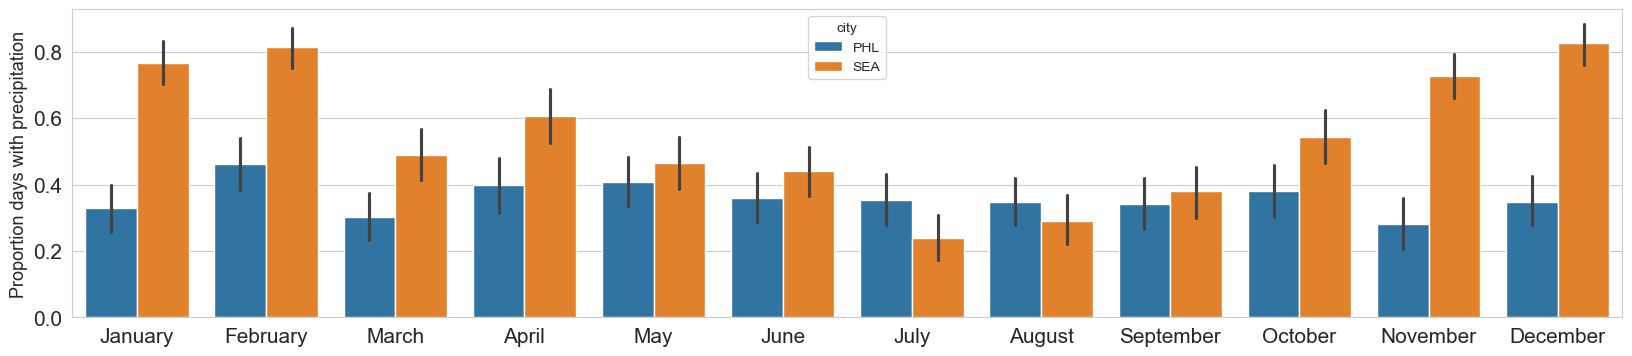

In [60]:
#Plot the proportion of days with precipitation each month

plt.figure(figsize=(20,4))

sns.barplot(data=df, x='month', y='any_precipitation', hue='city')

plt.xlabel(None)
plt.ylabel('Proportion days with precipitation', fontsize=13)
plt.xticks(ticks=range(12), labels=month_names)
plt.tick_params(labelsize=15)


#Save file to reports folder

plt.savefig('/Users/michael/Documents/SeattleU/5100/Weather/reports/monthly_rainfall_proportion.png', dpi=300, bbox_inches='tight')

plt.show()